<a href="https://colab.research.google.com/github/mohamadfaisalbashir/Practical-Linear-Algebra/blob/main/03_Vectors_Part2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Vectors, Part 2**

This notebook covers Vectors, Part 2:

1. Vector Sets
2. Linear Weighted Combination
3. Linear Independence
4. Subspace and Span
5. Basis
6. Summary

## **1. Vector Sets**

The simplest new concept in this chapter is the vector set: a collection of vectors, typically denoted with capital italic letters like S or V. Formally:

$$\mathbf{V} = \{\mathbf{v}_1, \ldots, \mathbf{v}_n\}$$

Vector sets can contain a finite or infinite number of vectors. An important special case is the empty set, denoted V = {}, which arises when studying matrix spaces (introduced in Chapter 6).

Vector sets can contain vectors from any real-valued dimension ℝᴺ, as long as all vectors in the set have the same dimensionality (otherwise, the operations we care about — particularly addition — would be undefined).

## **2. Linear Weighted Combination**

A linear weighted combination (also called a linear mixture or weighted combination) takes a set of vectors, multiplies each by a scalar weight, and sums the results to produce a single vector:

$$\mathbf{w} = \lambda_1\mathbf{v}_1 + \lambda_2\mathbf{v}_2 + \ldots + \lambda_n\mathbf{v}_n$$

All vectors must have the same dimensionality. The scalars λ can be any real number, including zero. Subtraction is a special case where a scalar is set to a negative value.

Cohen identifies linear weighted combination as one of the two most important elementary concepts in linear algebra (the other being the dot product). Its practical significance is enormous:

- Statistical models: Predicted values in a regression model are linear weighted combinations of predictor variables.
- PCA: Each principal component is a linear weighted combination of the original features, with weights chosen to maximize variance.
- Deep learning: Neural networks compute linear weighted combinations of inputs, followed by nonlinear activations.

In [1]:
import numpy as np

# Linear weighted combination of three vectors
l1 = 1
l2 = 2
l3 = -3

v1 = np.array([4, 5, 1])
v2 = np.array([-4, 0, -4])
v3 = np.array([1, 3, 2])

w = l1*v1 + l2*v2 + l3*v3
print(f'Result of linear weighted combination: {w}')
# Expected: [-7, -4, -13]

Result of linear weighted combination: [ -7  -4 -13]


## **3. Linear Independence**

Linear independence is a property of a *set* of vectors, not of any individual vector. A set of vectors is linearly dependent if at least one vector in the set can be expressed as a linear weighted combination of the other vectors. Conversely, the set is linearly independent if no vector can be expressed as a linear combination of the others.

Consider these two sets:
- V = {[1, 3], [2, 7]}: These are independent — no scalar λ satisfies v₁ = λv₂.
- S = {[1, 3], [2, 6]}: These are dependent — s₂ = 2·s₁ (and equally, s₁ = 0.5·s₂).

The set S has a redundant vector: both vectors point in the same direction.

### **3.1 The Math of Linear Independence**

The formal mathematical definition of linear dependence is:

$$\mathbf{0} = \lambda_1\mathbf{v}_1 + \lambda_2\mathbf{v}_2 + \ldots + \lambda_n\mathbf{v}_n, \quad \lambda \in \mathbb{R}$$

This says: a set is linearly dependent if there exist scalars (not all zero) such that their linear combination produces the zeros vector. Setting all λs to zero always satisfies this equation trivially — so we require that at least one λ ≠ 0.

Why frame it this way (equaling the zeros vector) rather than expressing one vector as a combination of others? Because writing it with the zeros vector on the left side treats all vectors in the set symmetrically — no individual vector is privileged as "the dependent one." Linear independence is a property of the whole set.

### **3.2 Independence and the Zeros Vector**

Any vector set that includes the zeros vector is automatically linearly dependent, because:

$$\lambda_0 \cdot \mathbf{0} = 0 \cdot \mathbf{v}_1 + 0 \cdot \mathbf{v}_2 + \ldots + 0 \cdot \mathbf{v}_n$$

As long as λ₀ ≠ 0, this is a nontrivial solution to the linear dependence equation.

In practice, to determine linear independence of a large vector set, one creates a matrix from the vectors and computes the matrix rank (introduced in Chapter 6).

## **4. Subspace and Span**

A subspace is what you get when you take a finite set of vectors and consider *all possible* linear weighted combinations — using the same vectors but allowing the scalars (weights) to take on any real value. The mechanism of generating all possible combinations is called the span of the vector set.

Think of span as a verb (the set *spans* a subspace) and subspace as a noun (the result of spanning is a *subspace*).

Examples:

- One vector in ℝ²: V = {[1, 3]}. Its span is a 1D subspace — a line through the origin in the direction of the vector. Any scaled version of [1, 3] lies on this line.

- Two independent vectors in ℝ³: Their span is a 2D subspace — a plane through the origin in 3D space.

- Two dependent vectors in ℝ³: Even with two vectors, if one is a scalar multiple of the other, the span is still only a 1D subspace (a line). The second vector is redundant.

The key relationship: the dimensionality of the spanned subspace equals the number of linearly independent vectors in the set — not simply the number of vectors.

The formal definition of a subspace requires that it is *closed under addition and scalar multiplication* and *contains the origin*. In plain language: any linear combination of vectors in the subspace must also be in the subspace (including scaling all vectors by zero, which gives the origin).

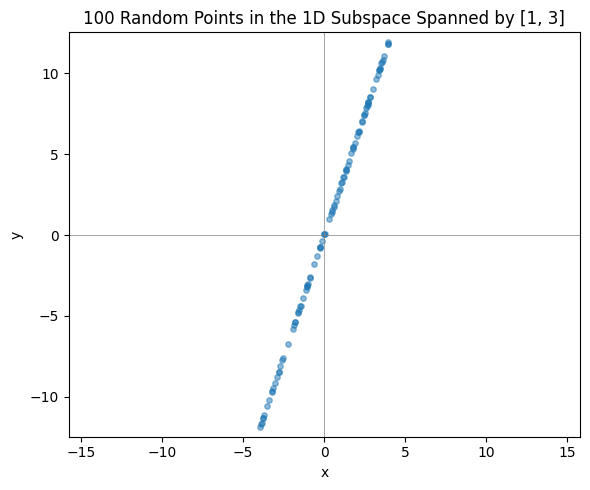

In [2]:
import matplotlib.pyplot as plt

# Visualize random points in a 1D subspace (a line)
basis_vector = np.array([1, 3])
scalars = np.random.uniform(-4, 4, 100)
points  = np.outer(scalars, basis_vector)

plt.figure(figsize=(6, 5))
plt.scatter(points[:, 0], points[:, 1], alpha=0.5, s=15)
plt.axhline(0, color='gray', lw=0.5)
plt.axvline(0, color='gray', lw=0.5)
plt.title('100 Random Points in the 1D Subspace Spanned by [1, 3]')
plt.xlabel('x'); plt.ylabel('y')
plt.axis('equal')
plt.tight_layout()
plt.show()

## **5. Basis**

Cohen introduces the concept of a basis through a wonderful analogy: a basis is like a *ruler* for measuring a space. Just as we can measure the same distance using miles, kilometers, or nanometers, we can describe the same data points using different basis sets — some of which are more convenient for certain problems than others.

### **5.1 Definition of Basis**

A set of vectors forms a basis for a subspace if it satisfies two conditions:

1. It spans that subspace (you can measure everything in it).
2. It is linearly independent (each vector in the basis is necessary — removing any one would reduce the span).

Why does independence matter for a basis? Because it guarantees uniqueness: each point in the subspace has exactly one representation as a linear combination of the basis vectors. A dependent set cannot guarantee this — with redundant vectors, a point can be described by infinitely many different combinations. Mathematicians insist on unique coordinates within a basis set.

### **5.2 The Standard Basis**

The most familiar basis is the Cartesian basis (standard basis), consisting of unit vectors along each axis:

$$\mathbf{S}_2 = \left\{\begin{bmatrix}1\\0\end{bmatrix}, \begin{bmatrix}0\\1\end{bmatrix}\right\}, \quad \mathbf{S}_3 = \left\{\begin{bmatrix}1\\0\\0\end{bmatrix}, \begin{bmatrix}0\\1\\0\end{bmatrix}, \begin{bmatrix}0\\0\\1\end{bmatrix}\right\}$$

These are mutually orthogonal and unit length — excellent properties. But they are not the only valid basis.

### **5.3 Why Bases Matter in Data Science**

Cohen makes a profound observation: many of the most important methods in applied data science can be understood as finding the best basis set for a particular problem:

> Dimension reduction, feature extraction, PCA, ICA, factor analysis, SVD, LDA, image compression — all of these are essentially ways of identifying optimal basis vectors for a specific problem.

Different basis sets are more or less appropriate for different tasks, and none is universally "best." The choice depends on the goals of the analysis, the features of the data, and the constraints of the method.

In [3]:
S = np.eye(2)  # standard basis
T = np.array([[3, -3], [1, 1]])  # alternate basis (columns are basis vectors)

p_standard = np.array([3, 1])
q_standard = np.array([-6, 2])

# Coordinates in T basis (solve: T @ coords = point)
p_in_T = np.linalg.solve(T, p_standard)
q_in_T = np.linalg.solve(T, q_standard)

print(f'Point p in standard basis: {p_standard}')
print(f'Point p in T basis:        {p_in_T}')
print()
print(f'Point q in standard basis: {q_standard}')
print(f'Point q in T basis:        {q_in_T}')

Point p in standard basis: [3 1]
Point p in T basis:        [1. 0.]

Point q in standard basis: [-6  2]
Point q in T basis:        [0. 2.]


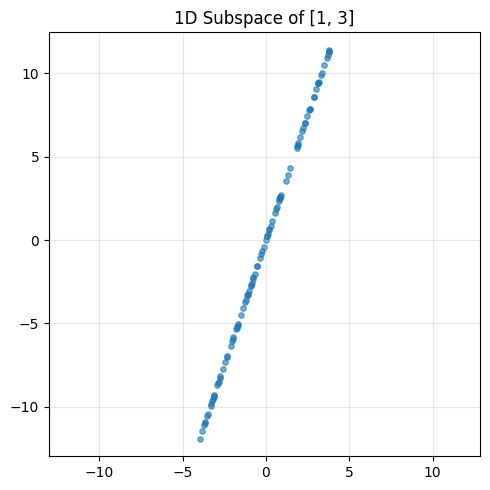


With dependent vectors, points still lie in a 1D subspace (a line).


In [4]:
basis_1d = np.array([1, 3])
scalars_1d = np.random.uniform(-4, 4, 100)
points_1d = np.outer(scalars_1d, basis_1d)

plt.figure(figsize=(5, 5))
plt.scatter(points_1d[:, 0], points_1d[:, 1], s=15, alpha=0.6)
plt.title('1D Subspace of [1, 3]')
plt.axis('equal'); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


v1_3d = np.array([3, 5, 1])
v2_3d = np.array([0, 2, 2])
scalars_3d = np.random.uniform(-4, 4, (100, 2))  # 100 x 2 random scalars
points_3d  = scalars_3d[:, 0:1] * v1_3d + scalars_3d[:, 1:2] * v2_3d

try:
    import plotly.graph_objects as go
    fig = go.Figure(data=[go.Scatter3d(
        x=points_3d[:, 0], y=points_3d[:, 1], z=points_3d[:, 2],
        mode='markers', marker=dict(size=3))])
    fig.update_layout(title='2D Subspace in ℝ³')
    fig.show()
except ImportError:
    print('plotly not available — install with: pip install plotly')
    print(f'Points shape: {points_3d.shape} (these lie on a 2D plane in 3D space)')

# Part C: Repeat with second vector = 0.5 * first vector (dependent set → 1D subspace)
v2_dep = 0.5 * v1_3d
points_dep = scalars_3d[:, 0:1] * v1_3d + scalars_3d[:, 1:2] * v2_dep
print(f'\nWith dependent vectors, points still lie in a 1D subspace (a line).')

## **6. Summary**

Chapter 3 elevates our understanding of vectors from individual objects to sets of vectors with structural properties. All the key ideas in this chapter ultimately reduce to a single elementary operation — **linear weighted combinations** — applied in different ways:

- A **vector set** is any collection of vectors.
- A **linear weighted combination** means scalar multiplying and adding vectors in a set — one of the most important operations in all of linear algebra.
- A set is **linearly dependent** if one vector can be expressed as a linear combination of the others; it is **linearly independent** if no such combination exists.
- A **subspace** is the infinite set of all possible linear weighted combinations of a set of vectors.
- The **dimensionality** of the subspace equals the number of linearly independent vectors in the spanning set.
- A **basis** is a linearly independent set of vectors that spans a subspace — effectively a measurement system (ruler) for that space. A major goal of data science is to discover the best basis for describing datasets or solving problems.

These ideas are critical prerequisites for understanding matrix rank, matrix spaces, eigendecomposition, and essentially all of the advanced topics in the second half of the book.